# NSE Sectoral Rotation Project
## Step 2 — Data Cleaning
Combining all 618 bhavcopy files into one master dataset

In [2]:
import pandas as pd
import glob
import os

# Find all CSV files in raw folder
files = glob.glob("../data/raw/*.csv")
print(f"Total files found: {len(files)}")

Total files found: 618


## Step 1 - Combine all 618 files into one master dataframe

In [3]:
dfs = []

for f in files:
    temp = pd.read_csv(f)
    dfs.append(temp)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {df_raw.shape[0]:,}")
print(f"Total columns: {df_raw.shape[1]}")
df_raw.head()

Total rows: 1,499,155
Total columns: 14


,SYMBOL,SERIES,OPEN,HIGH,LOW,CLOSE,LAST,PREVCLOSE,TOTTRDQTY,TOTTRDVAL,TIMESTAMP,TOTALTRADES,ISIN,Unnamed: 13
0,20MICRONS,EQ,73.80,81.20,73.10,81.20,81.20,73.85,337838,26809138.65,01-APR-2022,2964,INE144J01027,NaN
1,21STCENMGM,EQ,29.15,29.15,29.15,29.15,29.15,29.70,8378,244218.70,01-APR-2022,56,INE253B01015,NaN
2,3IINFOLTD,EQ,51.40,53.80,51.40,53.80,53.80,51.25,378205,20109170.75,01-APR-2022,1651,INE748C01038,NaN
3,3MINDIA,EQ,19710.00,20425.75,19680.00,19972.85,20000.00,19697.30,4284,85980389.55,01-APR-2022,2207,INE470A01017,NaN
4,3PLAND,EQ,14.50,15.20,14.00,15.15,15.15,14.50,8653,125818.85,01-APR-2022,95,INE105C01023,NaN


## Step 2 - Filter EQ stocks only and clean columns

In [4]:
# Filter EQ only
df = df_raw[df_raw["SERIES"] == "EQ"].copy()

# Clean column names
df.columns = df.columns.str.strip().str.upper()

# Keep useful columns only
df = df[["SYMBOL", "OPEN", "HIGH", "LOW", "CLOSE", "PREVCLOSE", "TOTTRDQTY", "TIMESTAMP"]]

# Fix date
df["DATE"] = pd.to_datetime(df["TIMESTAMP"], format="%d-%b-%Y")
df = df.drop(columns=["TIMESTAMP"])

print(f"After filtering: {df.shape[0]:,} rows")
print(f"Date range: {df['DATE'].min()} to {df['DATE'].max()}")
df.head()

After filtering: 1,115,058 rows
Date range: 2022-01-03 00:00:00 to 2024-07-05 00:00:00


,SYMBOL,OPEN,HIGH,LOW,CLOSE,PREVCLOSE,TOTTRDQTY,DATE
0,20MICRONS,73.80,81.20,73.10,81.20,73.85,337838,2022-04-01
1,21STCENMGM,29.15,29.15,29.15,29.15,29.70,8378,2022-04-01
2,3IINFOLTD,51.40,53.80,51.40,53.80,51.25,378205,2022-04-01
3,3MINDIA,19710.00,20425.75,19680.00,19972.85,19697.30,4284,2022-04-01
4,3PLAND,14.50,15.20,14.00,15.15,14.50,8653,2022-04-01


## Step 3 - Calculate Daily Returns

In [5]:
# Calculate daily return
df["RETURN"] = ((df["CLOSE"] - df["PREVCLOSE"]) / df["PREVCLOSE"]) * 100
df["RETURN"] = df["RETURN"].round(4)

# Remove extreme outliers
df = df[df["RETURN"].abs() <= 75].copy()

print(f"Rows after outlier removal: {df.shape[0]:,}")
df.head()

Rows after outlier removal: 1,114,940


,SYMBOL,OPEN,HIGH,LOW,CLOSE,PREVCLOSE,TOTTRDQTY,DATE,RETURN
0,20MICRONS,73.80,81.20,73.10,81.20,73.85,337838,2022-04-01,9.9526
1,21STCENMGM,29.15,29.15,29.15,29.15,29.70,8378,2022-04-01,-1.8519
2,3IINFOLTD,51.40,53.80,51.40,53.80,51.25,378205,2022-04-01,4.9756
3,3MINDIA,19710.00,20425.75,19680.00,19972.85,19697.30,4284,2022-04-01,1.3989
4,3PLAND,14.50,15.20,14.00,15.15,14.50,8653,2022-04-01,4.4828


## Step 4 - Sector Mapping

In [6]:
sector_map = {
    "INFY": "IT", "TCS": "IT", "WIPRO": "IT",
    "HCLTECH": "IT", "TECHM": "IT", "LTIM": "IT",
    "MPHASIS": "IT", "COFORGE": "IT", "PERSISTENT": "IT",
    "HDFCBANK": "BANKING", "ICICIBANK": "BANKING",
    "SBIN": "BANKING", "AXISBANK": "BANKING",
    "KOTAKBANK": "BANKING", "INDUSINDBK": "BANKING",
    "BANDHANBNK": "BANKING", "FEDERALBNK": "BANKING",
    "SUNPHARMA": "PHARMA", "DRREDDY": "PHARMA",
    "CIPLA": "PHARMA", "DIVISLAB": "PHARMA",
    "BIOCON": "PHARMA", "AUROPHARMA": "PHARMA",
    "LUPIN": "PHARMA", "ALKEM": "PHARMA",
    "MARUTI": "AUTO", "TATAMOTORS": "AUTO",
    "M&M": "AUTO", "BAJAJ-AUTO": "AUTO",
    "HEROMOTOCO": "AUTO", "EICHERMOT": "AUTO",
    "ASHOKLEY": "AUTO", "TVSMOTOR": "AUTO",
    "HINDUNILVR": "FMCG", "ITC": "FMCG",
    "NESTLEIND": "FMCG", "BRITANNIA": "FMCG",
    "DABUR": "FMCG", "MARICO": "FMCG",
    "GODREJCP": "FMCG", "COLPAL": "FMCG",
    "RELIANCE": "ENERGY", "ONGC": "ENERGY",
    "NTPC": "ENERGY", "POWERGRID": "ENERGY",
    "BPCL": "ENERGY", "IOC": "ENERGY",
    "GAIL": "ENERGY", "ADANIGREEN": "ENERGY",
    "BAJFINANCE": "FINANCE", "BAJAJFINSV": "FINANCE",
    "HDFCLIFE": "FINANCE", "SBILIFE": "FINANCE",
    "ICICIPRULI": "FINANCE", "MUTHOOTFIN": "FINANCE",
    "TATASTEEL": "METALS", "JSWSTEEL": "METALS",
    "HINDALCO": "METALS", "VEDL": "METALS",
    "SAIL": "METALS", "COALINDIA": "METALS",
}

df["SECTOR"] = df["SYMBOL"].map(sector_map)
df_sectors = df.dropna(subset=["SECTOR"]).copy()

print(f"Mapped stocks: {df_sectors.shape[0]:,} rows")
print(df_sectors["SECTOR"].value_counts())

Mapped stocks: 37,467 rows
SECTOR
IT         5334
ENERGY     4944
PHARMA     4944
AUTO       4944
BANKING    4944
FMCG       4943
FINANCE    3707
METALS     3707
Name: count, dtype: int64


## Step 5 - Check Missing Values

In [7]:
print("Missing values:")
print(df_sectors.isnull().sum())
print(f"\nUnique stocks: {df_sectors['SYMBOL'].nunique()}")
print(f"Unique trading days: {df_sectors['DATE'].nunique()}")
print(f"Date range: {df_sectors['DATE'].min()} to {df_sectors['DATE'].max()}")

Missing values:
SYMBOL       0
OPEN         0
HIGH         0
LOW          0
CLOSE        0
PREVCLOSE    0
TOTTRDQTY    0
DATE         0
RETURN       0
SECTOR       0
dtype: int64

Unique stocks: 61
Unique trading days: 618
Date range: 2022-01-03 00:00:00 to 2024-07-05 00:00:00


## Step 6 - Calculate Sector Returns and Save Master CSVs

In [8]:
# Sector returns — average return per sector per day
sector_returns = df_sectors.groupby(["SECTOR", "DATE"])["RETURN"].mean().reset_index()
sector_returns.columns = ["SECTOR", "DATE", "AVG_RETURN"]
sector_returns["AVG_RETURN"] = sector_returns["AVG_RETURN"].round(4)

# Save all 3 master files
df_sectors.to_csv("../data/master_stocks.csv", index=False)
sector_returns.to_csv("../data/sector_returns.csv", index=False)

print(f"✅ master_stocks.csv saved — {df_sectors.shape[0]:,} rows")
print(f"✅ sector_returns.csv saved — {sector_returns.shape[0]:,} rows")
print("\nSector returns preview:")
sector_returns.head(10)

✅ master_stocks.csv saved — 37,467 rows
✅ sector_returns.csv saved — 4,944 rows

Sector returns preview:


,SECTOR,DATE,AVG_RETURN
0,AUTO,2022-01-03,1.8217
1,AUTO,2022-01-04,0.0252
2,AUTO,2022-01-05,1.6571
3,AUTO,2022-01-06,0.7654
4,AUTO,2022-01-07,-0.2811
5,AUTO,2022-01-10,1.7342
6,AUTO,2022-01-11,-0.2281
7,AUTO,2022-01-12,1.5703
8,AUTO,2022-01-13,0.3523
9,AUTO,2022-01-14,-0.5433


## Step 7 - Distribution Plots

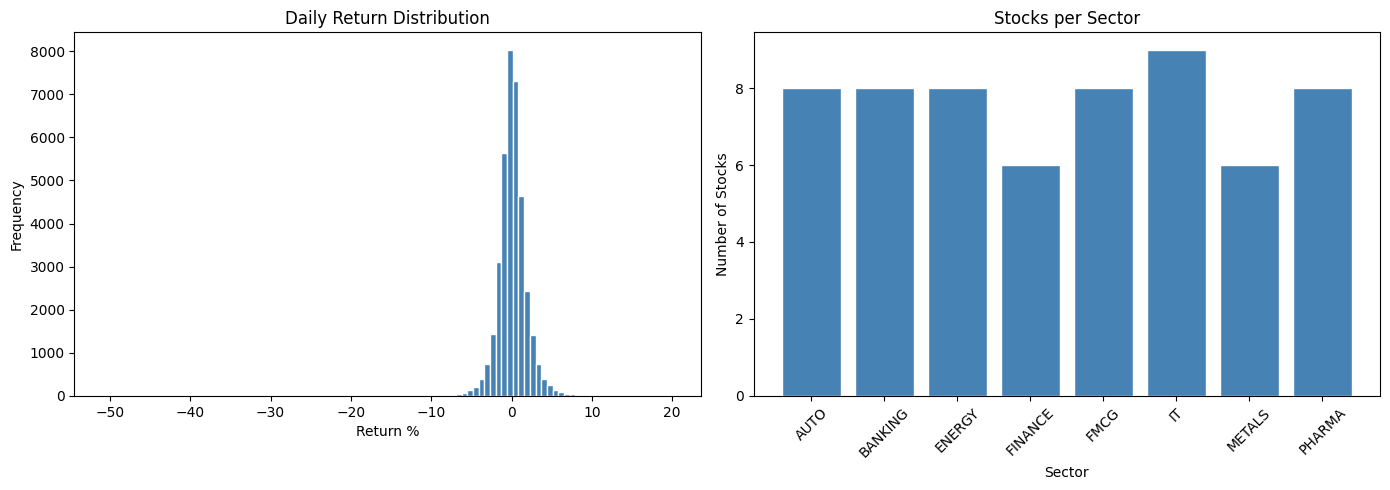

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Return distribution
axes[0].hist(df_sectors["RETURN"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("Daily Return Distribution")
axes[0].set_xlabel("Return %")
axes[0].set_ylabel("Frequency")

# Plot 2 — Stocks per sector
sector_counts = df_sectors.groupby("SECTOR")["SYMBOL"].nunique()
axes[1].bar(sector_counts.index, sector_counts.values, color="steelblue", edgecolor="white")
axes[1].set_title("Stocks per Sector")
axes[1].set_xlabel("Sector")
axes[1].set_ylabel("Number of Stocks")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Step 8 - Download NIFTY 50 Data (Benchmark)

In [10]:
import yfinance as yf

nifty = yf.download("^NSEI", start="2022-01-01", end="2024-12-31")
nifty = nifty[["Close"]].reset_index()
nifty.columns = ["DATE", "NIFTY_CLOSE"]
nifty["DATE"] = pd.to_datetime(nifty["DATE"])
nifty["NIFTY_RETURN"] = nifty["NIFTY_CLOSE"].pct_change() * 100
nifty["NIFTY_RETURN"] = nifty["NIFTY_RETURN"].round(4)
nifty = nifty.dropna()

nifty.to_csv("../data/index_returns.csv", index=False)
print(f"✅ index_returns.csv saved — {nifty.shape[0]} rows")
print(f"Date range: {nifty['DATE'].min()} to {nifty['DATE'].max()}")
nifty.head()

[*********************100%***********************]  1 of 1 completed

✅ index_returns.csv saved — 737 rows
Date range: 2022-01-04 00:00:00 to 2024-12-30 00:00:00


,DATE,NIFTY_CLOSE,NIFTY_RETURN
1,2022-01-04,17805.250000,1.0187
2,2022-01-05,17925.250000,0.6740
3,2022-01-06,17745.900391,-1.0005
4,2022-01-07,17812.699219,0.3764
5,2022-01-10,18003.300781,1.0700
